## Chapter 4 — Regression and Prediction

**Buku:** *Practical Statistics for Data Scientists* (O'Reilly)

Chapter ini membahas simple dan multiple linear regression, model assessment, cross-validation, model selection, weighted regression, factor variables, interpretation, diagnostics, polynomial regression, splines, dan GAM.



## 1. Simple Linear Regression
Model:
**Y = b₀ + b₁X + ε**

Istilah penting: response/target (Y), predictor/feature (X), intercept (b₀), regression coefficient/slope (b₁), fitted value (Ŷ), dan residual (Y−Ŷ). Contoh PDF menggunakan `Exposure` untuk memprediksi `PEFR`. fileciteturn7file0L2-L9


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
from statsmodels.stats.outliers_influence import OLSInfluence

sns.set_theme(style="whitegrid")
BASE="https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/"
lung=pd.read_csv(BASE+"LungDisease.csv")
house=pd.read_csv(BASE+"house_sales.csv",sep="\t")
print(lung.shape, house.shape)
display(lung.head(), house.head())


(122, 2) (22687, 22)


,PEFR,Exposure
0,390,0
1,410,0
2,430,0
3,460,0
4,420,1


,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,...,Bathrooms,Bedrooms,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction
1,2014-09-16,280000,1000102,Multiplex,2014-09-01,405100,0.930836,300805.0,2,9373,...,3.00,6,7,1991,0,0,70000,229000,98002,False
2,2006-06-16,1000000,1200013,Single Family,2006-06-01,404400,0.929228,1076162.0,1,20156,...,3.75,4,10,2005,0,0,203000,590000,98166,True
3,2007-01-29,745000,1200019,Single Family,2007-01-01,425600,0.977941,761805.0,1,26036,...,1.75,4,8,1947,0,0,183000,275000,98166,False
4,2008-02-25,425000,2800016,Single Family,2008-02-01,418400,0.961397,442065.0,1,8618,...,3.75,5,7,1966,0,0,104000,229000,98168,False
5,2013-03-29,240000,2800024,Single Family,2013-03-01,351600,0.807904,297065.0,1,8620,...,1.75,4,7,1948,0,0,104000,205000,98168,False


Intercept: 424.582806573957
Exposure coefficient: -4.184576485461442


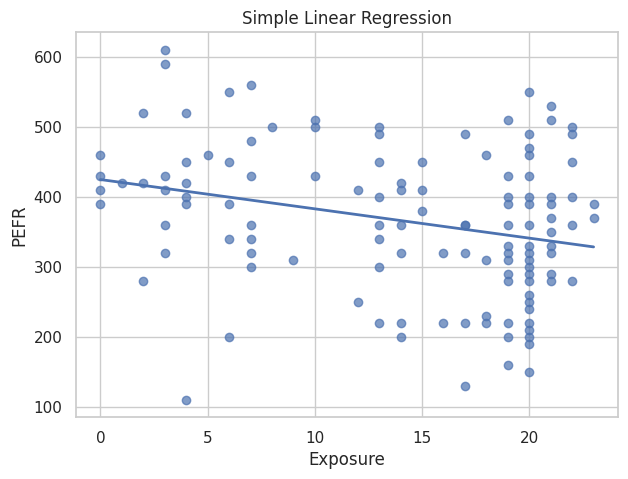

In [2]:
predictors=["Exposure"]; outcome="PEFR"
lm=LinearRegression().fit(lung[predictors],lung[outcome])
print("Intercept:",lm.intercept_)
print("Exposure coefficient:",lm.coef_[0])
x=np.linspace(lung.Exposure.min(),lung.Exposure.max(),100)
plt.figure(figsize=(7,5))
plt.scatter(lung.Exposure,lung.PEFR,alpha=.7)
plt.plot(x,lm.predict(pd.DataFrame({"Exposure":x})),linewidth=2)
plt.xlabel("Exposure"); plt.ylabel("PEFR"); plt.title("Simple Linear Regression")
plt.show()


### Fitted values, residuals, dan least squares
Fitted value: **Ŷᵢ = b̂₀ + b̂₁Xᵢ**. Residual: **êᵢ = Yᵢ − Ŷᵢ**. Least squares memilih koefisien yang meminimalkan RSS = Σ(Yᵢ−Ŷᵢ)². fileciteturn7file0L7-L10


RSS: 1234764.2857142857 RMSE: 100.60327397934422


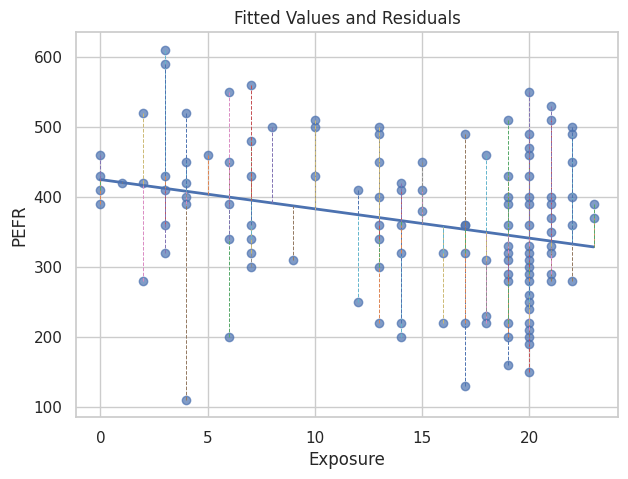

In [3]:
fitted=lm.predict(lung[predictors])
resid=lung[outcome].to_numpy()-fitted
print("RSS:",np.sum(resid**2),"RMSE:",np.sqrt(np.mean(resid**2)))
plt.figure(figsize=(7,5))
plt.scatter(lung.Exposure,lung.PEFR,alpha=.7)
plt.plot(lung.Exposure,fitted,linewidth=2)
for x,y,yp in zip(lung.Exposure,lung.PEFR,fitted): plt.plot([x,x],[y,yp],"--",linewidth=.7)
plt.title("Fitted Values and Residuals"); plt.xlabel("Exposure"); plt.ylabel("PEFR"); plt.show()


## 2. Multiple Linear Regression
Model:
**Y = b₀ + b₁X₁ + ... + bₚXₚ + ε**

Contoh King County housing menggunakan `SqFtTotLiving`, `SqFtLot`, `Bathrooms`, `Bedrooms`, dan `BldgGrade` untuk memprediksi `AdjSalePrice`. fileciteturn7file0L11-L15


In [4]:
predictors=["SqFtTotLiving","SqFtLot","Bathrooms","Bedrooms","BldgGrade"]
outcome="AdjSalePrice"
house_lm=LinearRegression().fit(house[predictors],house[outcome])
print("Intercept:",house_lm.intercept_)
display(pd.DataFrame({"Predictor":predictors,"Coefficient":house_lm.coef_}))


Intercept: -521871.36818828376


,Predictor,Coefficient
0,SqFtTotLiving,228.830604
1,SqFtLot,-0.060467
2,Bathrooms,-19442.840398
3,Bedrooms,-47769.955185
4,BldgGrade,106106.963079


In [5]:
pred=house_lm.predict(house[predictors])
rmse=np.sqrt(mean_squared_error(house[outcome],pred))
r2=r2_score(house[outcome],pred)
print("RMSE:",rmse,"R²:",r2)
ols=sm.OLS(house[outcome],sm.add_constant(house[predictors])).fit()
print(ols.summary())


RMSE: 261220.19743696266 R²: 0.5405875253381902
                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.541
Model:                            OLS   Adj. R-squared:                  0.540
Method:                 Least Squares   F-statistic:                     5338.
Date:                Thu, 01 Oct 2026   Prob (F-statistic):               0.00
Time:                        22:57:25   Log-Likelihood:            -3.1517e+05
No. Observations:               22687   AIC:                         6.304e+05
Df Residuals:                   22681   BIC:                         6.304e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------

## 3. Model Assessment dan Cross-Validation
RMSE mengukur besar error prediksi; R² mengukur proporsi variasi response yang dijelaskan model. Untuk memperkirakan performa pada data baru, gunakan cross-validation. Chapter menjelaskan k-fold cross-validation pada halaman 13–16. fileciteturn7file0L14-L17


In [6]:
kf=KFold(n_splits=5,shuffle=True,random_state=42)
scores=np.sqrt(-cross_val_score(LinearRegression(),house[predictors],house[outcome],cv=kf,scoring="neg_mean_squared_error"))
print("RMSE per fold:",np.round(scores,2))
print("Mean CV RMSE:",scores.mean())


RMSE per fold: [272593.82 288085.13 242633.61 231706.08 268491.03]
Mean CV RMSE: 260701.9317504325


## 4. Model Selection dan Weighted Regression
Chapter membahas all-subset/stepwise selection, adjusted R², AIC, BIC, Mallows Cp, serta weighted regression. Menambah predictor tidak otomatis membuat model lebih baik.


In [7]:
sets=[
["SqFtTotLiving"],
["SqFtTotLiving","SqFtLot"],
["SqFtTotLiving","SqFtLot","Bathrooms"],
["SqFtTotLiving","SqFtLot","Bathrooms","Bedrooms"],
["SqFtTotLiving","SqFtLot","Bathrooms","Bedrooms","BldgGrade"]]
rows=[]
for cols in sets:
    r=sm.OLS(house[outcome],sm.add_constant(house[cols])).fit()
    rows.append([", ".join(cols),np.sqrt(np.mean(r.resid**2)),r.rsquared,r.rsquared_adj,r.aic,r.bic])
display(pd.DataFrame(rows,columns=["Predictors","RMSE","R2","Adjusted_R2","AIC","BIC"]))


,Predictors,RMSE,R2,Adjusted_R2,AIC,BIC
0,SqFtTotLiving,277047.488425,0.483230,0.483207,633011.353537,633027.412632
1,"SqFtTotLiving, SqFtLot",277047.251615,0.483230,0.483185,633013.314753,633037.403395
2,"SqFtTotLiving, SqFtLot, Bathrooms",277044.567046,0.483240,0.483172,633014.875080,633046.993270
3,"SqFtTotLiving, SqFtLot, Bathrooms, Bedrooms",272275.566148,0.500878,0.500790,632229.013611,632269.161348
4,"SqFtTotLiving, SqFtLot, Bathrooms, Bedrooms, B...",261220.197437,0.540588,0.540486,630350.218464,630398.395748


In [8]:
hw=house.copy()
hw["Year"]=hw["DocumentDate"].str[:4].astype(int)
hw["Weight"]=hw["Year"]-2005
weighted=LinearRegression().fit(hw[predictors],hw[outcome],sample_weight=hw.Weight)
display(pd.DataFrame({"Predictor":predictors+["intercept"],
"Ordinary":list(house_lm.coef_)+[house_lm.intercept_],
"Weighted":list(weighted.coef_)+[weighted.intercept_]}))


,Predictor,Ordinary,Weighted
0,SqFtTotLiving,228.830604,245.024089
1,SqFtLot,-0.060467,-0.292415
2,Bathrooms,-19442.840398,-26085.970109
3,Bedrooms,-47769.955185,-53608.876436
4,BldgGrade,106106.963079,115242.434726
5,intercept,-521871.368188,-584189.329446


## 5. Factor Variables
Categorical/factor variables perlu direpresentasikan numerik untuk regression. Metode yang dibahas meliputi dummy variables dan reference coding. Untuk factor dengan P level, regression dengan intercept biasanya memakai P−1 dummy untuk menghindari perfect multicollinearity.

In [9]:
print(house.PropertyType.head())
display(pd.get_dummies(house.PropertyType,dtype=int).head())
Xf=pd.get_dummies(house[["SqFtTotLiving","SqFtLot","Bathrooms","Bedrooms","BldgGrade","PropertyType"]],drop_first=True,dtype=int)
fm=LinearRegression().fit(Xf,house[outcome])
display(pd.Series(fm.coef_,index=Xf.columns).sort_values())


1        Multiplex
2    Single Family
3    Single Family
4    Single Family
5    Single Family
Name: PropertyType, dtype: object


,Multiplex,Single Family,Townhouse
1,1,0,0
2,0,1,0
3,0,1,0
4,0,1,0
5,0,1,0


,0
PropertyType_Townhouse,-115121.979216
PropertyType_Single Family,-84678.216295
Bedrooms,-50889.732185
Bathrooms,-15979.013473
SqFtLot,-0.070368
SqFtTotLiving,223.373629
BldgGrade,109416.305161


## 6. Interpreting Regression: Correlation, Multicollinearity, Confounding, Interaction
Correlated predictors dapat menyulitkan interpretasi koefisien. Multicollinearity dapat membuat koefisien tidak stabil. Confounding terjadi ketika predictor penting yang berkaitan dengan predictor dan response tidak dimasukkan. Interaction berarti efek suatu predictor bergantung pada predictor lain.

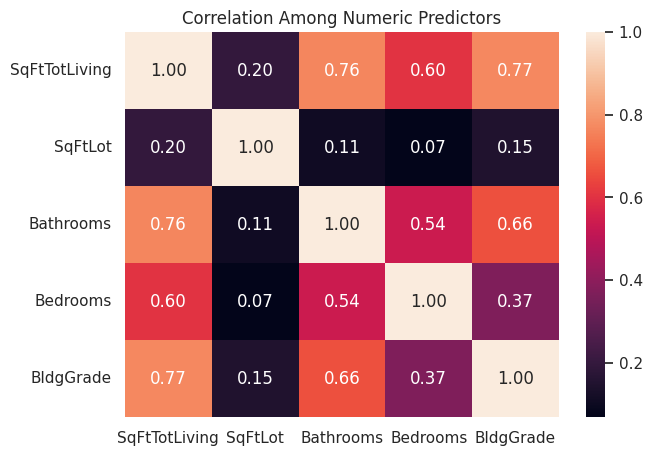

In [10]:
plt.figure(figsize=(7,5))
sns.heatmap(house[predictors].corr(),annot=True,fmt=".2f")
plt.title("Correlation Among Numeric Predictors"); plt.show()


In [11]:
h=house.copy()
h["ZipGroup"]=pd.qcut(h["ZipCode"].rank(method="first"),5,labels=False)
interaction=smf.ols("AdjSalePrice ~ SqFtTotLiving*ZipGroup + SqFtLot + Bathrooms + Bedrooms + BldgGrade",data=h).fit()
print(interaction.summary())


                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.549
Model:                            OLS   Adj. R-squared:                  0.548
Method:                 Least Squares   F-statistic:                     3937.
Date:                Thu, 01 Oct 2026   Prob (F-statistic):               0.00
Time:                        22:58:47   Log-Likelihood:            -3.1497e+05
No. Observations:               22687   AIC:                         6.300e+05
Df Residuals:                   22679   BIC:                         6.300e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept              -6.50

## 7. Regression Diagnostics
Diagnostics digunakan untuk mendeteksi outliers, influential values, leverage, non-normal residuals, heteroskedasticity, dan kemungkinan ketidakcocokan model.


Minimum studentized residual: -4.326731804078571 index: 258


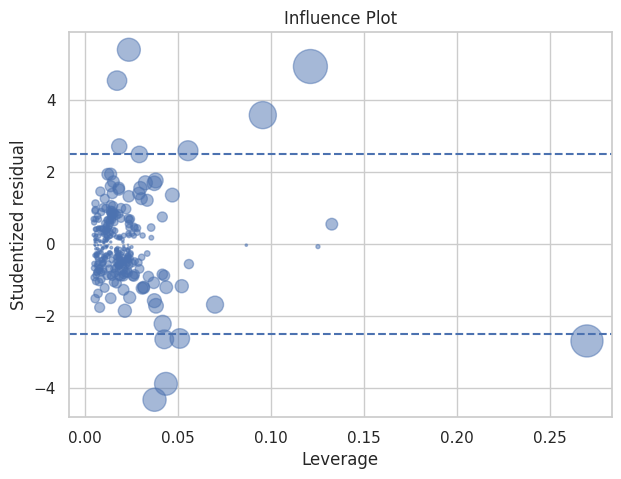

In [12]:
h98105=house.loc[house.ZipCode==98105].copy()
cols=["SqFtTotLiving","SqFtLot","Bathrooms","Bedrooms","BldgGrade"]
diag=sm.OLS(h98105[outcome],sm.add_constant(h98105[cols])).fit()
infl=OLSInfluence(diag)
sr=infl.resid_studentized_internal
print("Minimum studentized residual:",sr.min(),"index:",sr.argmin())
cook=infl.cooks_distance[0]
plt.figure(figsize=(7,5))
plt.scatter(infl.hat_matrix_diag,sr,s=800*np.sqrt(cook+1e-12),alpha=.5)
plt.axhline(2.5,ls="--"); plt.axhline(-2.5,ls="--")
plt.xlabel("Leverage"); plt.ylabel("Studentized residual"); plt.title("Influence Plot"); plt.show()


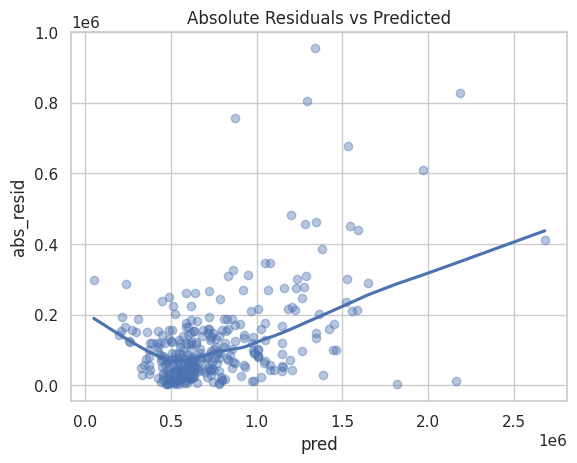

In [13]:
d=pd.DataFrame({"pred":diag.fittedvalues,"resid":diag.resid})
d["abs_resid"]=d.resid.abs()
sns.regplot(data=d,x="pred",y="abs_resid",lowess=True,scatter_kws={"alpha":.4})
plt.title("Absolute Residuals vs Predicted"); plt.show()


## 8. Partial Residuals dan Nonlinearity
Partial residual plots membantu mengevaluasi hubungan satu predictor dengan outcome setelah memperhitungkan predictor lain. Chapter menggunakan contoh `SqFtTotLiving` dan menunjukkan kemungkinan hubungan nonlinear. fileciteturn7file0L45-L48


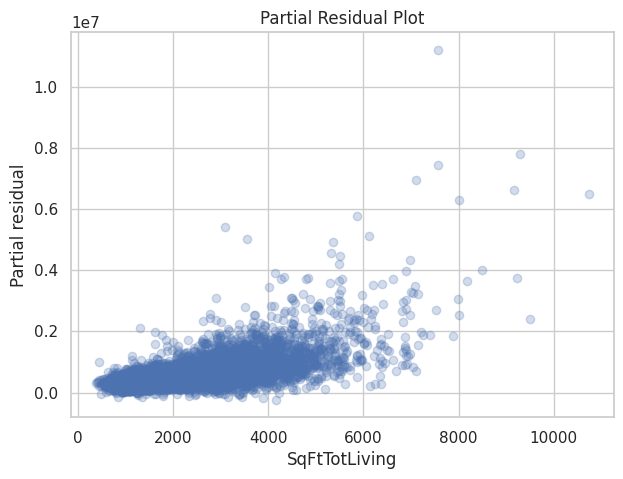

In [14]:
full=sm.OLS(house[outcome],sm.add_constant(house[predictors])).fit()
beta=full.params["SqFtTotLiving"]
partial=full.resid+beta*house["SqFtTotLiving"]
plt.figure(figsize=(7,5))
plt.scatter(house.SqFtTotLiving,partial,alpha=.25)
plt.xlabel("SqFtTotLiving"); plt.ylabel("Partial residual"); plt.title("Partial Residual Plot"); plt.show()


## 9. Polynomial Regression
Hubungan nonlinear dapat dimodelkan dengan polynomial terms, misalnya:
**Y = b₀ + b₁X + b₂X² + ε**.
Chapter memberikan contoh polynomial regression untuk `SqFtTotLiving`. fileciteturn7file0L48-L50


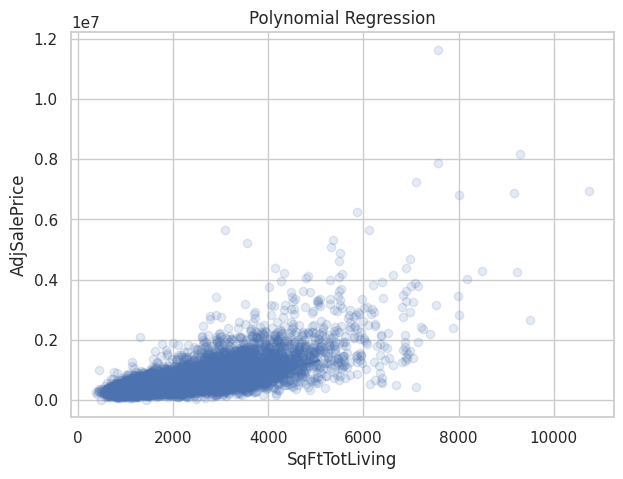

In [15]:
hp=house.copy()
hp["SqFtTotLiving2"]=hp.SqFtTotLiving**2
pp=predictors+["SqFtTotLiving2"]
pm=LinearRegression().fit(hp[pp],hp[outcome])
x=np.linspace(hp.SqFtTotLiving.quantile(.01),hp.SqFtTotLiving.quantile(.99),200)
grid=pd.DataFrame({"SqFtTotLiving":x,"SqFtLot":hp.SqFtLot.median(),"Bathrooms":hp.Bathrooms.median(),
"Bedrooms":hp.Bedrooms.median(),"BldgGrade":hp.BldgGrade.median(),"SqFtTotLiving2":x**2})
plt.figure(figsize=(7,5)); plt.scatter(hp.SqFtTotLiving,hp[outcome],alpha=.15); plt.plot(x,pm.predict(grid),linewidth=2)
plt.xlabel("SqFtTotLiving"); plt.ylabel("AdjSalePrice"); plt.title("Polynomial Regression"); plt.show()


## 10. Splines dan Generalized Additive Models
Spline regression menggunakan potongan polynomial yang disambungkan pada **knots**. GAM menggunakan fungsi smooth untuk menangkap hubungan nonlinear secara fleksibel. Kedua topik dibahas pada halaman 49–53 PDF. fileciteturn7file0L50-L54


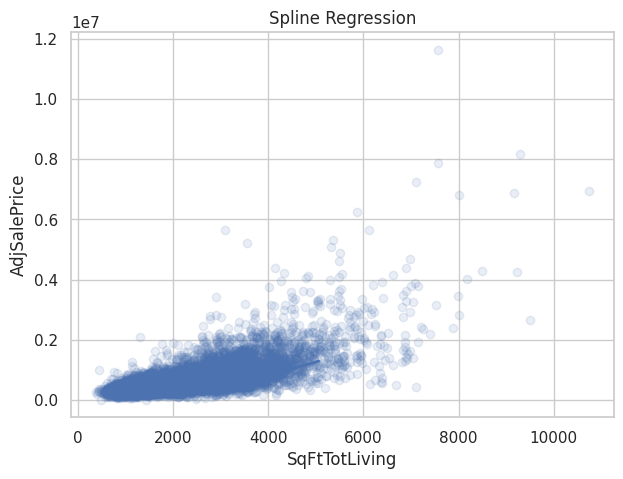

In [16]:
spline=smf.ols("AdjSalePrice ~ bs(SqFtTotLiving, df=6) + SqFtLot + Bathrooms + Bedrooms + BldgGrade",data=house).fit()
x=np.linspace(house.SqFtTotLiving.quantile(.01),house.SqFtTotLiving.quantile(.99),200)
grid=pd.DataFrame({"SqFtTotLiving":x,"SqFtLot":house.SqFtLot.median(),"Bathrooms":house.Bathrooms.median(),
"Bedrooms":house.Bedrooms.median(),"BldgGrade":house.BldgGrade.median()})
plt.figure(figsize=(7,5)); plt.scatter(house.SqFtTotLiving,house[outcome],alpha=.12); plt.plot(x,spline.predict(grid),linewidth=2)
plt.xlabel("SqFtTotLiving"); plt.ylabel("AdjSalePrice"); plt.title("Spline Regression"); plt.show()


In [18]:
!pip -q install pygam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 2.2 MB/s eta 0:00:00


In [19]:
try:
    from pygam import LinearGAM,s,l
    Xg=house[["SqFtTotLiving","SqFtLot","Bathrooms","Bedrooms","BldgGrade"]].to_numpy()
    yg=house[outcome].to_numpy()
    gam=LinearGAM(s(0,n_splines=12)+s(1,n_splines=10)+l(2)+l(3)+l(4)).fit(Xg,yg)
    print(gam.summary())
except ImportError:
    print("pygam belum tersedia. Di Colab jalankan: !pip -q install pygam")


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     16.6622
Link Function:                     IdentityLink Log Likelihood:                               -313381.6839
Number of Samples:                        22687 AIC:                                           626798.6922
                                                AICc:                                          626798.7213
                                                GCV:                                      58408225683.6708
                                                Scale:                                         241518.1477
                                                Pseudo R-Squared:                                   0.6076
Feature Function                  Lam

/tmp/ipykernel_1007/2500692181.py:6: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary())


## 11. Ringkasan dan Kesimpulan
- Regression memodelkan hubungan response dan predictor.
- Least squares meminimalkan RSS.
- Multiple regression menggunakan beberapa predictor.
- RMSE dan R² membantu menilai model, sedangkan cross-validation membantu menilai generalisasi.
- Factor variables perlu encoding yang sesuai.
- Multicollinearity, confounding, interaction, outliers, leverage, Cook's distance, dan heteroskedasticity perlu diperiksa.
- Polynomial regression, splines, dan GAM dapat menangkap hubungan nonlinear.

**Kesimpulan:** model regression tidak cukup dinilai dari R² saja; interpretasi, diagnostics, dan performa pada data baru juga penting. PDF menutup chapter dengan penekanan pada prediction, model fit, dan variable selection. fileciteturn7file0L54-L55
